* notation
    * $n$: 脑区数量
    * $X \in \mathbb{R}^{n \times g}$
    * $Y \in \mathbb{R}^{n \times t}$
* PLS analysis
    * z-score columnwise for both $X$ and $Y$
    * $(Y^{T} X)^T = USV^{T} \in \mathbb{R}^{g \times t}$, 奇异值分解
        * $U = [U_1, \cdots, U_t] \in \mathbb{R}^{g \times t}$, $U_i$ latent variable
        * $V = [V_1, \cdots, V_t] \in \mathbb{R}^{t \times t}$, $V_i$ latent variable
        * $S = diag(\sigma_1, \cdot, \sigma_t) \in \mathbb{R}^{t \times t}$, $\lambda_id$ 代表$U_i$和$V_i$之间的`covariance`
    * `Explained ratio`, $r_i = \sigma_i^2 / \sum\limits_{j} \sigma_j^2$
    * `Gene weights`, $U_i$, 对每个基因对潜变量的贡献
    * `Term weights`, $T_i$, 每个term对潜变量的贡献
    * `Gene score`, $G_i = XU_i \in \mathbb{R}^{n}$
    * `Term score`, $T_i = YV_i \in \mathbb{R}^{b}$
    * `Gene loading`, $Pearson(G_i, X[:, j])$
    * `Term loading`, $Pearson(T_i, Y[:, j])$

In [1]:
!pip install plotnine --upgrade

In [30]:
!unzip pyls.zip -d ./HumanEEGNeurosynth_WM/

Archive:  pyls.zip
  inflating: ./HumanEEGNeurosynth_WM/pyls/__init__.py  
   creating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/__init__.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/_version.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/base.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/compute.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/io.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/structures.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/__pycache__/utils.cpython-38.pyc  
  inflating: ./HumanEEGNeurosynth_WM/pyls/_version.py  
  inflating: ./HumanEEGNeurosynth_WM/pyls/base.py  
  inflating: ./HumanEEGNeurosynth_WM/pyls/compute.py  
   creating: ./HumanEEGNeurosynth_WM/pyls/examples/
  inflating: ./HumanEEGNeurosynth_WM/pyls/examples/__init__.py  
   creating: ./HumanEEGNeurosynth_WM/pyls/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as p9
from sklearn.preprocessing import scale
from scipy.stats import zscore

from pyls import pls_regression
from statsmodels.stats.multitest import fdrcorrection

import pickle

## Posi + Nega

In [25]:
# ===== 根据基因得分正负分离表达数据 =====
import pandas as pd

# 1. 读取新的基因得分文件（两列格式）
new_gene_score = pd.read_csv( 
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_increase_coupling_kwx.csv",   # 替换为实际文件路径
    index_col=0,  # 第一列为基因名称
    header=0      # 第一行为列标题
)

# 2. 读取已生成的top10基因表达数据
top10_expr = pd.read_csv( 
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/expr_left_top10_activate_kwx.csv", 
    index_col=0
)

# 3. 提取基因得分列（假设第二列名为'score'）
score_column = new_gene_score.columns[0]   # 自动获取得分列名

# 4. 筛选正负得分基因
positive_genes = []
negative_genes = []

for gene in top10_expr.columns: 
    if gene in new_gene_score.index: 
        score = new_gene_score.loc[gene,  score_column]
        if score > 0:
            positive_genes.append(gene) 
        elif score < 0:
            negative_genes.append(gene) 

# 5. 创建分离后的表达数据集
positive_expr = top10_expr[positive_genes]
negative_expr = top10_expr[negative_genes]

# 6. 保存结果文件
positive_expr.to_csv( 
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/expr_left_top10_activate_increase_positive_kwx.csv" 
)
negative_expr.to_csv( 
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/expr_left_top10_activate_increase_negative_kwx.csv" 
)

# 7. 输出统计信息
print(f"🔍 基因分离完成:")
print(f"   - 原始基因数量: {len(top10_expr.columns)}") 
print(f"   - 正向得分基因: {len(positive_genes)}")
print(f"   - 负向得分基因: {len(negative_genes)}")
print(f"   - 零值/缺失基因: {len(top10_expr.columns)  - len(positive_genes) - len(negative_genes)}")
print(f"💾 文件已保存至:")
print(f"   - 正向基因: expr_left_top10_activate_increase_positive.csv") 
print(f"   - 负向基因: expr_left_top10_activate_increase_negative.csv") 

🔍 基因分离完成:
   - 原始基因数量: 1563
   - 正向得分基因: 437
   - 负向得分基因: 197
   - 零值/缺失基因: 929
💾 文件已保存至:
   - 正向基因: expr_left_top10_activate_increase_positive.csv
   - 负向基因: expr_left_top10_activate_increase_negative.csv


In [26]:
expr_top10_posi = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/expr_left_top10_activate_increase_positive_kwx.csv", index_col=0)
expr_top10_nega = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/expr_left_top10_activate_increase_negative_kwx.csv", index_col=0)
expr_top10 = pd.concat((expr_top10_posi, expr_top10_nega), axis=1)
expr_top10.shape

(64, 634)

In [27]:
brain_map = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/03.neuromaps/res/brain_map2_left.pkl")


flag = np.array([ (i, j, i.split(".")[-1].split("-")[-1].lower() == j) for i, j in zip(expr_top10.index, brain_map.index)])
flag[flag[:, 2]=='False', :]

array([['Left-Thalamus-Proper', 'thalamusproper', 'False'],
       ['Left-Accumbens-area', 'accumbensarea', 'False']], dtype='<U29')

In [28]:
receptor_idx = []
for i in brain_map.columns.to_list():
    if i[1] in [ 'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', "Glutamate", 'GABA', "Histamine", "Cannabin", 'Opioid', ]:
        receptor_idx.append(True)
    else:
        receptor_idx.append(False)

receptor_map = brain_map.loc[:, receptor_idx]
macro_map = brain_map.loc[:, ~np.array(receptor_idx)]
receptor_map.shape, macro_map.shape

((64, 19), (64, 31))

In [29]:
surrogate = pd.read_pickle("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/03.neuromaps/res/spin_surrogate.pkl").values
surrogate.shape

(64, 10000)

### Receptors

In [30]:
X = zscore(expr_top10.values, axis=0)
Y = zscore(receptor_map.values, axis=0)
plsr_receptor = pls_regression(X, Y, n_perm=10000, n_boot=10000, n_components=19, permsamples=surrogate)

In [31]:
with open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/plsr_receptor.posi_nega_activate_increase_kwx.pkl", "wb") as out:
    pickle.dump(plsr_receptor, out)

In [32]:
X = zscore(expr_top10.values, axis=0)
Y = zscore(receptor_map.values, axis=0)
plsr_receptor = pls_regression(X, Y, n_perm=1000, n_boot=1000, n_components=19)

<Figure size 600x400 with 0 Axes>

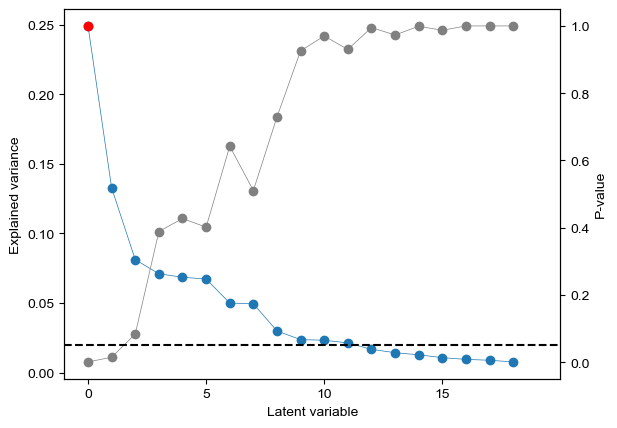

In [33]:
from matplotlib import rcParams
rcParams["font.family"] = "Arial"

idx = plsr_receptor.varexp.argsort()[::-1]
plt.figure(figsize=(6, 4))
fig, ax1 = plt.subplots()
ax1.plot(plsr_receptor.varexp[idx], "o-", linewidth=0.5)
ax1.plot(0, plsr_receptor.varexp[idx][0], "o", color="red")
ax1.set_xlabel("Latent variable")
ax1.set_ylabel("Explained variance")
ax1.set_xlim(-1, 20)
ax1.set_xticks([0, 5, 10, 15], [0, 5, 10, 15])
#ax1.set_yticks([0, 0.1, 0.2], [0, 0.1, 0.2])

ax2 = ax1.twinx()
ax2.plot(plsr_receptor.permres.pvals[idx], "o-", c="gray", linewidth=0.5)
ax2.axhline(y=0.05, c='black', linestyle="dashed")
ax2.set_ylabel("P-value")

plt.savefig("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/2.4pls_recptor_pval_activate_increase.png", dpi=300)
plt.show()

In [34]:
idx = plsr_receptor.varexp.argsort()[::-1]
pls1_boot = plsr_receptor.bootres.y_loadings_boot[:, idx[0], :]
mu = pls1_boot.mean(axis=1)
std = pls1_boot.std(axis=1)

dat_bar = pd.DataFrame( plsr_receptor.bootres.y_loadings[:, idx[0]], columns=["Loading"])
dat_bar["X"] = [ i[0] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = [ i[1] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = pd.Categorical(dat_bar["Class"], categories=['Microstructure', 'Function', 'Cortical expansion', 'Metabolism', 'Dynamics/Electrophysiology', 'Scaling', 'Others',
                                                                'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', 'Glutamate', 'GABA', 'Histamine', 'Cannabin', 'Opioid'])
dat_bar["Low"] = plsr_receptor.bootres.y_loadings[:, idx[0]] - pls1_boot.std(axis=1)
dat_bar["High"] = plsr_receptor.bootres.y_loadings[:, idx[0]] + pls1_boot.std(axis=1)
dat_bar.sort_values("Loading", inplace=True)
dat_bar["X"] = pd.Categorical(dat_bar["X"], categories=dat_bar["X"])

In [ ]:
from matplotlib import rcParams
rcParams["font.family"] = "Arial"

# 原始8色（秋润流金）
base_colors = ["#c72d47", "#ee8a49", "#f9b565", "#f9d286",
               "#ede29f", "#b4cda5", "#6fbdb9", "#346c9a"]

# 生成16色平滑渐变
cmap = LinearSegmentedColormap.from_list("custom", base_colors)
expanded_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, 16)]

# 建立 Class -> 颜色 映射
class_order = dat_bar["Class"].cat.categories
class_colors = {cls: expanded_colors[i] for i, cls in enumerate(class_order)}

bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.8, color="black", size=0.5)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    + p9.scale_fill_manual(values=class_colors)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed")
    + p9.theme_classic()
    + p9.ylab("Loadings")
    #+ p9.ylim(-6, 9)
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 4),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/pls_receptor_PLS1.posi_nega_activate_increase_kwx.pdf", format="pdf", width=9, height=4, units="in", verbose=False)
bar_plot

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


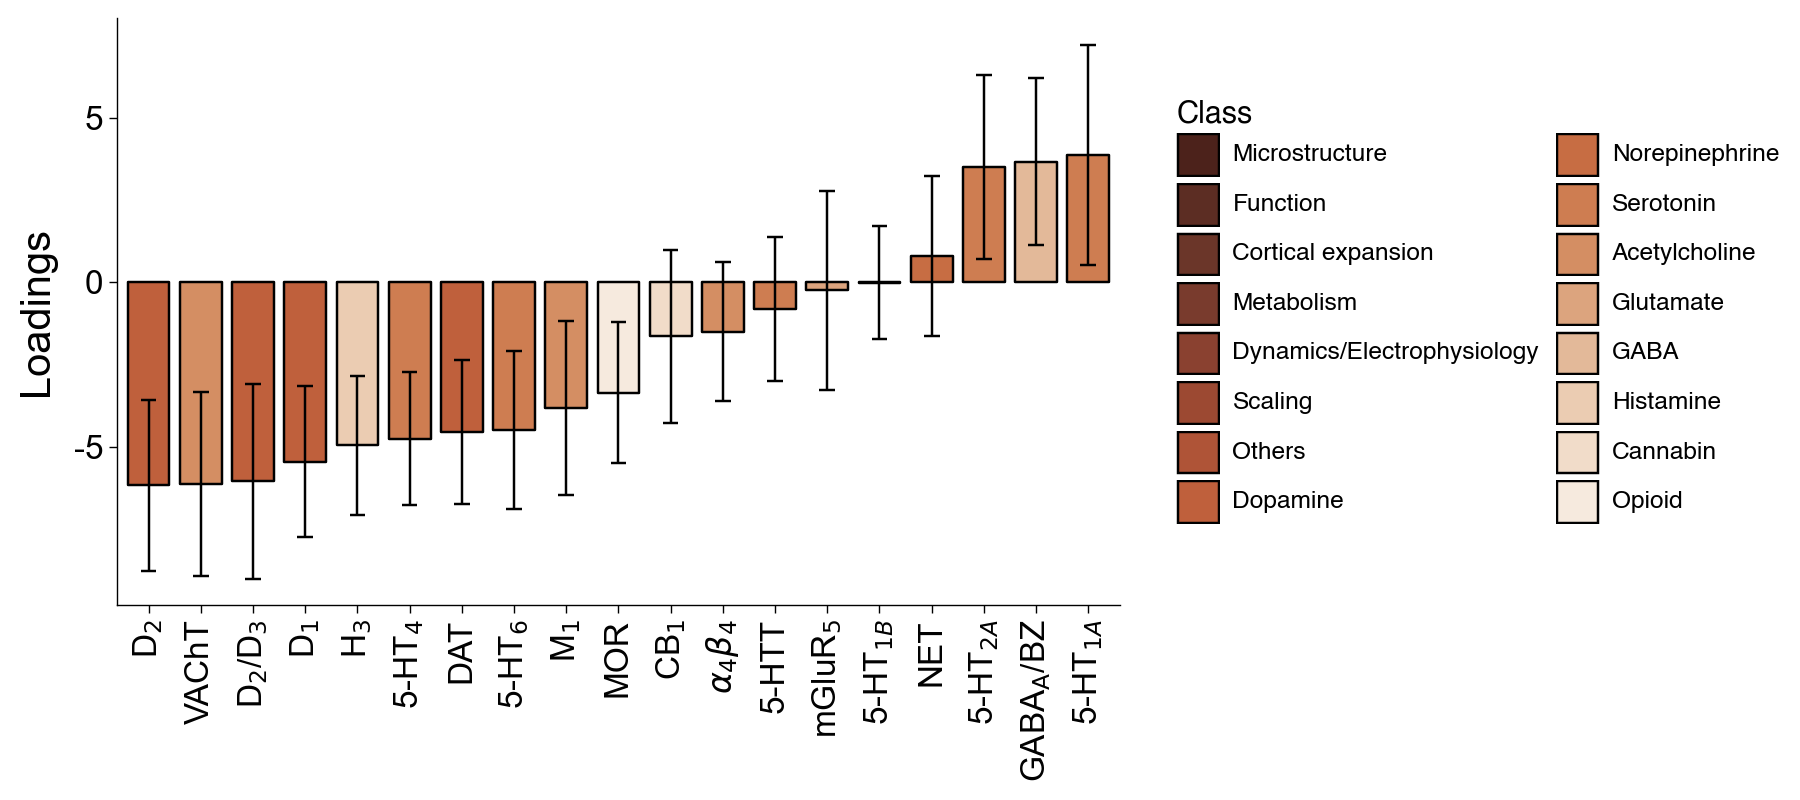

In [35]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np

from matplotlib import rcParams
rcParams["font.family"] = "Arial"

# 原始8色（秋润流金）
base_colors = ["#4C221B", "#663528", "#7E3C2E", "#9C4932", "#BC5C3A", "#CA7145", "#D48E63", "#E1B390", "#EDD2BB", "#F6EADE"]

# 生成16色平滑渐变
cmap = LinearSegmentedColormap.from_list("custom", base_colors)
expanded_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, 16)]

# 建立 Class -> 颜色 映射
class_order = dat_bar["Class"].cat.categories
class_colors = {cls: expanded_colors[i] for i, cls in enumerate(class_order)}

receptor_label_map = {
    "D1": r"D$_{1}$",
    "D2": r"D$_{2}$",
    "D2/D3": r"D$_{2}$/D$_{3}$",

    "5-HT/1A": r"5-HT$_{1A}$",
    "5-HT/2A": r"5-HT$_{2A}$",
    "5-HT/1B": r"5-HT$_{1B}$",
    "5-HT/4": r"5-HT$_{4}$",
    "5-HT/6": r"5-HT$_{6}$",

    "5-HT1A": r"5-HT$_{1A}$",
    "5-HT2A": r"5-HT$_{2A}$",
    "5-HT1B": r"5-HT$_{1B}$",
    "5-HT4": r"5-HT$_{4}$",
    "5-HT6": r"5-HT$_{6}$",

    "GABA-A/BZ": r"GABA$_{\mathrm{A}}$/BZ",
    "mGluR5": r"mGluR$_{5}$",
    "CB1": r"CB$_{1}$",
    "H3": r"H$_{3}$",
    "M1": r"M$_{1}$",

    "A4B4": r"$\alpha_{4}\beta_{4}$",
}

bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.8, color="black", size=0.5)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    + p9.scale_fill_manual(values=class_colors)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed")
    + p9.theme_classic()
    + p9.scale_x_discrete(labels=lambda x: [receptor_label_map.get(i, i) for i in x])
    + p9.ylab("Loadings")
    #+ p9.ylim(-6, 9)
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 4),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/2.4pls_receptor_PLS1_activate_increase.png", format="png", width=9, height=4, units="in", dpi=300, verbose=False)
bar_plot

In [13]:
idx = plsr_receptor.varexp.argsort()[::-1]
pls1_boot = plsr_receptor.bootres.y_loadings_boot[:, idx[1], :]
mu = pls1_boot.mean(axis=1)
std = pls1_boot.std(axis=1)

#dat_bar = pd.DataFrame( (plsr_receptor.bootres.y_loadings[:, idx[0]] - 0)/std, columns=["Loading"])
dat_bar = pd.DataFrame( plsr_receptor.bootres.y_loadings[:, idx[1]], columns=["Loading"])
dat_bar["X"] = [ i[0] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = [ i[1] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = pd.Categorical(dat_bar["Class"], categories=['Microstructure', 'Function', 'Cortical expansion', 'Metabolism', 'Dynamics/Electrophysiology', 'Scaling', 'Others',
                                                                'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', 'Glutamate', 'GABA', 'Histamine', 'Cannabin', 'Opioid'])
dat_bar["Low"] = plsr_receptor.bootres.y_loadings[:, idx[1]] - pls1_boot.std(axis=1)
dat_bar["High"] = plsr_receptor.bootres.y_loadings[:, idx[1]] + pls1_boot.std(axis=1)
dat_bar.sort_values("Loading", inplace=True)
dat_bar["X"] = pd.Categorical(dat_bar["X"], categories=dat_bar["X"])

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


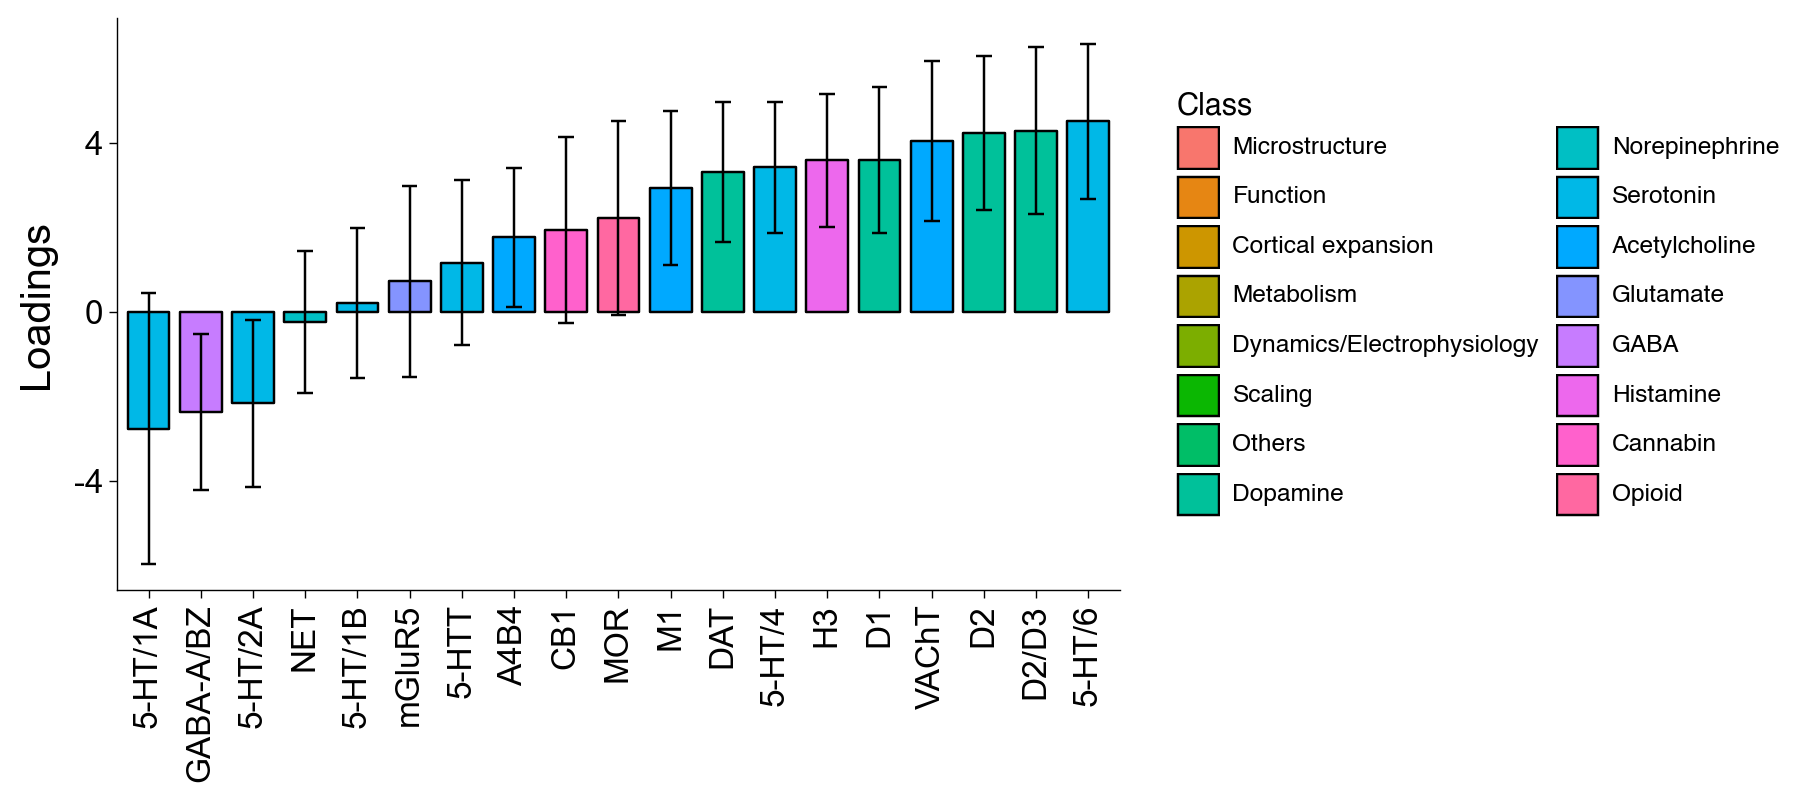

In [39]:
bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.8, color="black", size=0.5)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed")
    + p9.theme_classic()
    + p9.ylab("Loadings")
    #+ p9.ylim(-6, 9)
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 4),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/pls_receptor_PLS2.posi_nega_activate_increase_kwx.pdf", format="pdf", width=9, height=4, units="in", verbose=False)
bar_plot

In [15]:
idx = plsr_receptor.varexp.argsort()[::-1]
pls1_boot = plsr_receptor.bootres.y_loadings_boot[:, idx[2], :]
mu = pls1_boot.mean(axis=1)
std = pls1_boot.std(axis=1)

#dat_bar = pd.DataFrame( (plsr_receptor.bootres.y_loadings[:, idx[0]] - 0)/std, columns=["Loading"])
dat_bar = pd.DataFrame( plsr_receptor.bootres.y_loadings[:, idx[2]], columns=["Loading"])
dat_bar["X"] = [ i[0] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = [ i[1] for i in receptor_map.columns.to_list() ]
dat_bar["Class"] = pd.Categorical(dat_bar["Class"], categories=['Microstructure', 'Function', 'Cortical expansion', 'Metabolism', 'Dynamics/Electrophysiology', 'Scaling', 'Others',
                                                                'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', 'Glutamate', 'GABA', 'Histamine', 'Cannabin', 'Opioid'])
dat_bar["Low"] = plsr_receptor.bootres.y_loadings[:, idx[2]] - pls1_boot.std(axis=1)
dat_bar["High"] = plsr_receptor.bootres.y_loadings[:, idx[2]] + pls1_boot.std(axis=1)
dat_bar.sort_values("Loading", inplace=True)
dat_bar["X"] = pd.Categorical(dat_bar["X"], categories=dat_bar["X"])

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


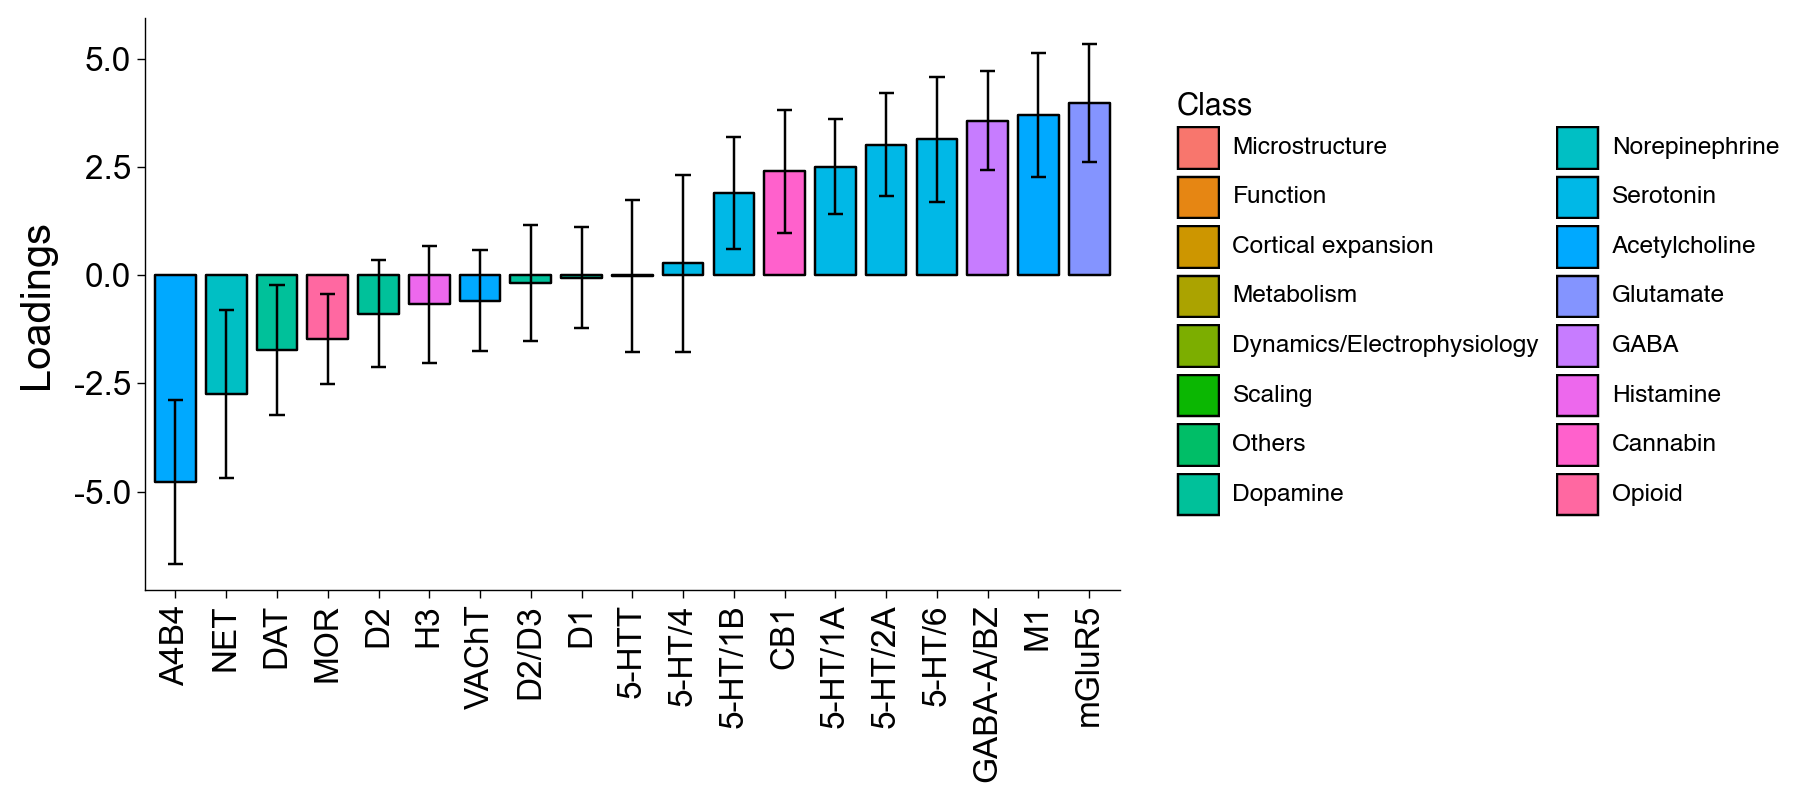

In [16]:
bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.8, color="black", size=0.5)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed")
    + p9.theme_classic()
    + p9.ylab("Loadings")
    #+ p9.ylim(-6, 9)
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 4),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/pls_receptor_PLS3.posi_nega_activate_increase_kwx.pdf", format="pdf", width=9, height=4, units="in", verbose=False)
bar_plot

#### explore CellChatDB

In [36]:
interaction_db = pd.read_excel("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/processed/04.CellChat/neuron_interactionDB_human.xlsx")
receptor_db = interaction_db.loc[interaction_db["interaction_type"]=="Neurotransmitter", :]
receptor_db = receptor_db.loc[receptor_db["lig_contributor"]=="ligand-receptor", :]

use_db = receptor_db["ligand_type"].str.split("_", expand=True)
use_db.columns = ["Ligand", "Receptor"]
use_db["Type"] = use_db["Ligand"] + "-" + receptor_db["Receptor type"]
use_db.shape

(104, 3)

In [37]:
gene_score = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_increase_coupling_kwx.csv", header=None)
gene_score[0].isin(use_db["Receptor"]).sum()

np.int64(4)

In [38]:
expr_top10.columns.isin(use_db["Receptor"]).sum()

np.int64(4)

In [39]:
idx = use_db["Receptor"].isin(expr_top10.columns)
use_db.loc[idx, :]

,Ligand,Receptor,Type
97,Ach,CHRNA2,Ach-Nicotinic (Alpha)
128,5HT,HTR1E,5HT-HTR1
132,5HT,HTR2C,5HT-HTR2
152,Epi,ADRA1D,Epi-Alpha1
161,NE,ADRA1D,NE-Alpha1


### Marco

In [40]:
## surface
X = zscore(expr_top10.values[:57, :], axis=0)
Y = zscore(macro_map.values[:57, :], axis=0)

plsr_macro = pls_regression(X, Y, n_perm=10000, n_boot=10000, n_components=31, permsamples=surrogate[:57, :])

In [41]:
with open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/plsr_marco.posi_nega_activate_increase_kwx.pkl", "wb") as out:
    pickle.dump(plsr_macro, out)

<Figure size 600x400 with 0 Axes>

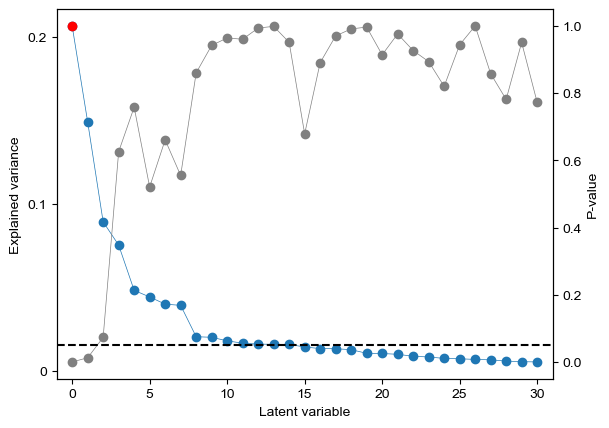

In [42]:
idx = plsr_macro.varexp.argsort()[::-1]
plt.figure(figsize=(6, 4))
fig, ax1 = plt.subplots()
ax1.plot(plsr_macro.varexp[idx], "o-", linewidth=0.5)
ax1.plot(0, plsr_macro.varexp[idx][0], "o", color="red")
ax1.set_xlabel("Latent variable")
ax1.set_ylabel("Explained variance")
ax1.set_xlim(-1, 31)
ax1.set_yticks([0, 0.1, 0.2], [0, 0.1, 0.2])


ax2 = ax1.twinx()
ax2.plot(plsr_macro.permres.pvals[idx], "o-", c="gray", linewidth=0.5)
ax2.axhline(y=0.05, c='black', linestyle="dashed")
ax2.set_ylabel("P-value")
plt.savefig("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/2.4pls_macro_pval_activate_increase.png", dpi=300)
plt.show()

In [43]:
idx = plsr_macro.varexp.argsort()[::-1]
pls1_boot = plsr_macro.bootres.y_loadings_boot[:, idx[0], :]
mu = pls1_boot.mean(axis=1)
std = pls1_boot.std(axis=1)

#dat_bar = pd.DataFrame( (plsr_macro.bootres.y_loadings[:, idx[0]] - 0)/std, columns=["Loading"])
dat_bar = pd.DataFrame( plsr_macro.bootres.y_loadings[:, idx[0]], columns=["Loading"])
dat_bar["X"] = [ i[0] for i in macro_map.columns.to_list() ]
dat_bar["Class"] = [ i[1] for i in macro_map.columns.to_list() ]
dat_bar["Class"] = pd.Categorical(dat_bar["Class"], categories=['Microstructure', 'Function', 'Cortical expansion', 'Metabolism', 'Dynamics/Electrophysiology', 'Scaling', 'Others',
                                                                'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', 'Glutamate', 'GABA', 'Histamine', 'Cannabin', 'Opioid'])
dat_bar["Low"] = plsr_macro.bootres.y_loadings[:, idx[0]] - std
dat_bar["High"] = plsr_macro.bootres.y_loadings[:, idx[0]] + std
dat_bar.sort_values("Loading", inplace=True)
dat_bar["X"] = pd.Categorical(dat_bar["X"], categories=dat_bar["X"])

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


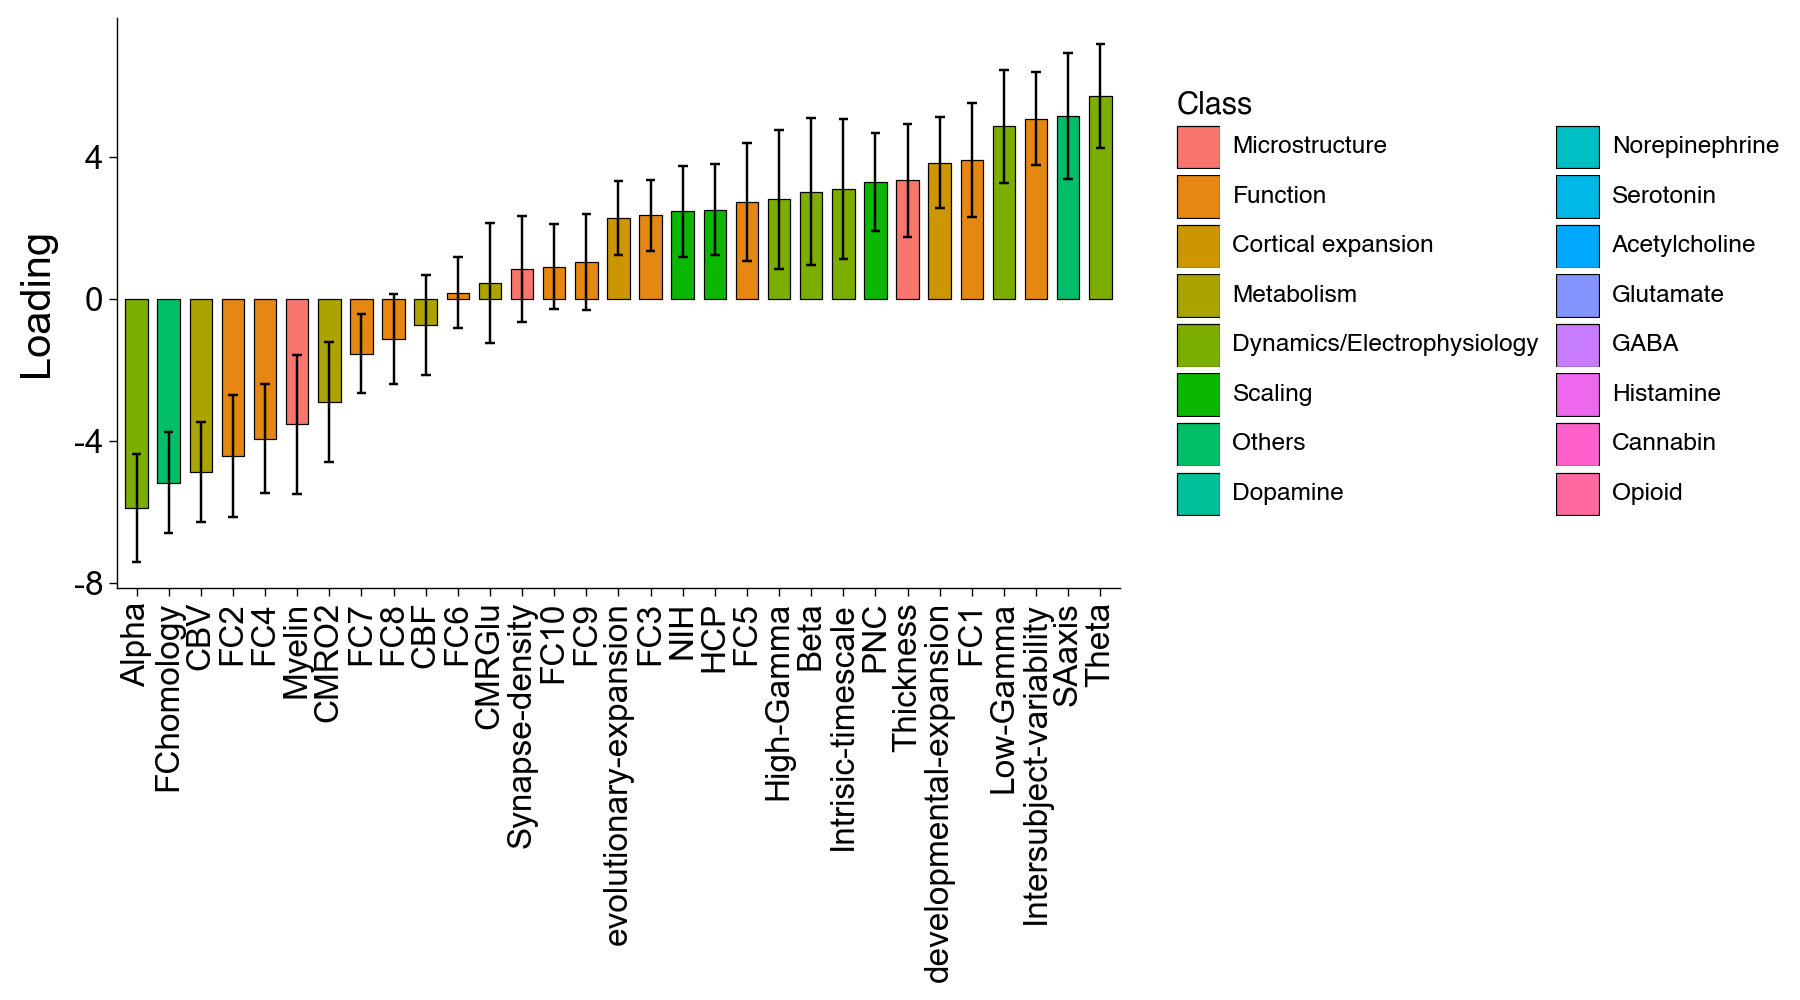

In [21]:
bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.7, color="black", size=0.25)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed", size=0.5)
    + p9.theme_classic()
    + p9.ylab("Loading")
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 5),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               #strip_text=p9.element_text(size=6, family="Arial"),
                axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/pls_macro_PLS1.posi_nega_activate_increase_kwx.pdf", format="pdf", width=13, height=5, units="in", verbose=False)
bar_plot

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


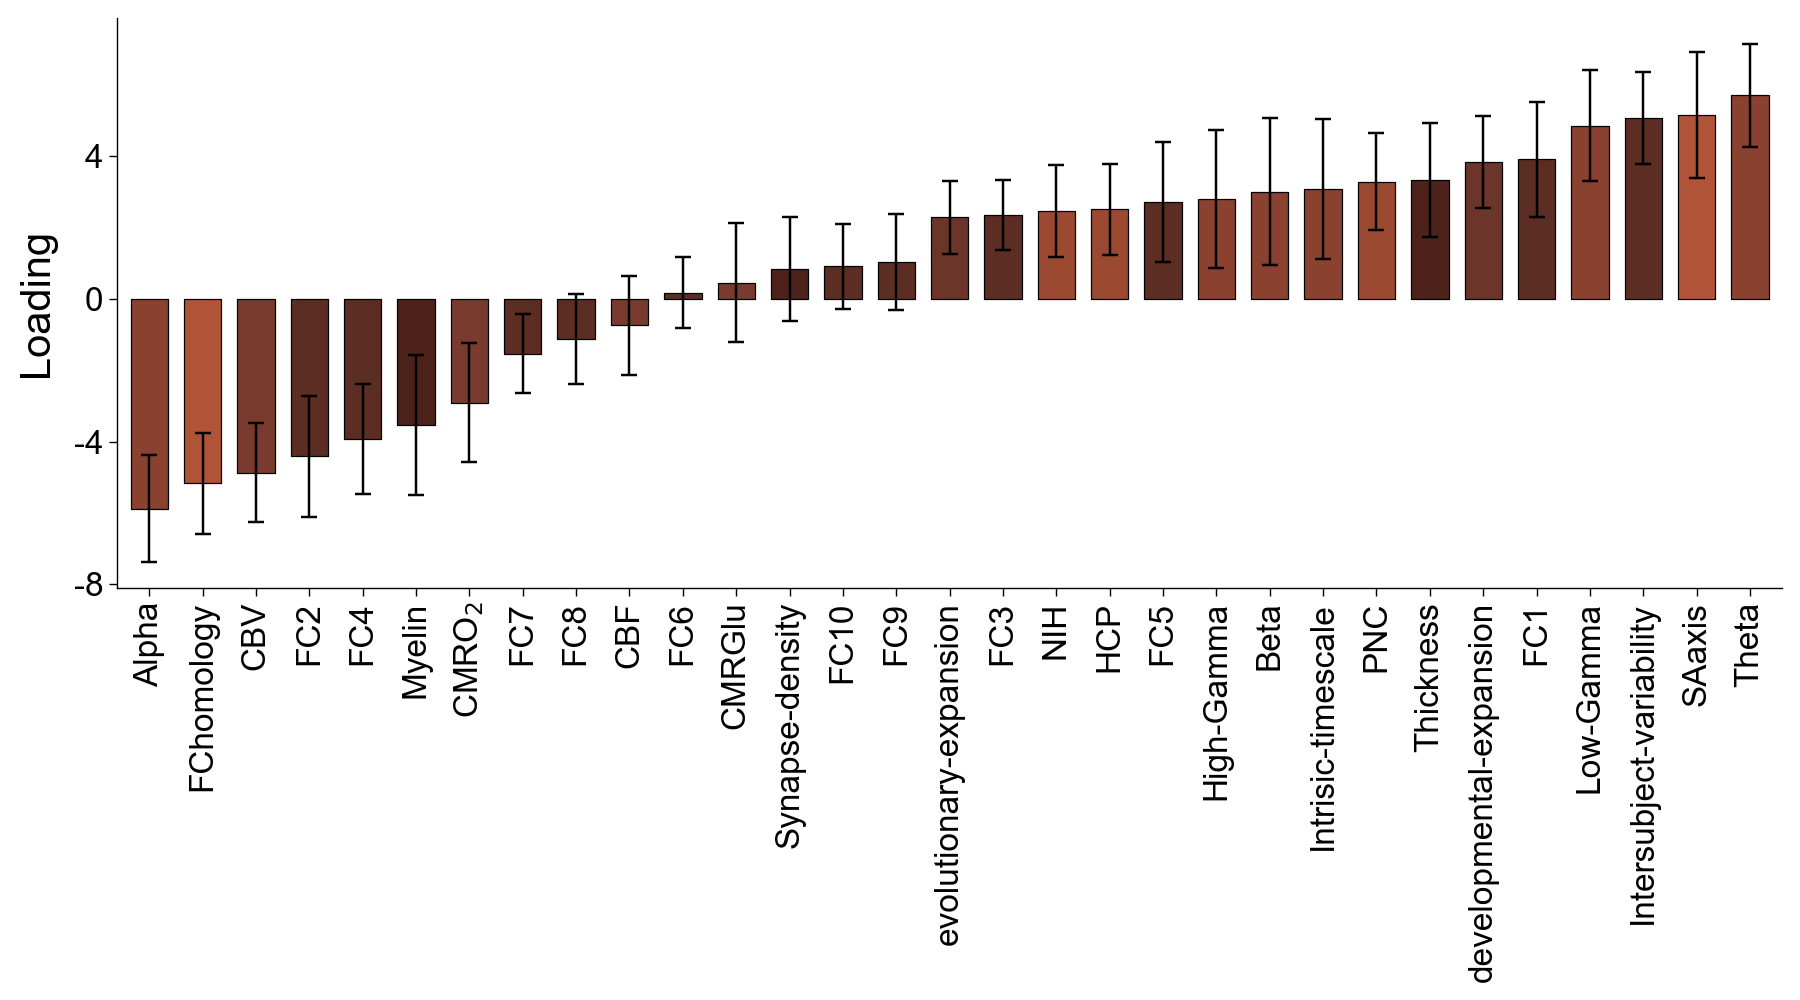

In [45]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np
from matplotlib import rcParams
rcParams["font.family"] = "Arial"

# 原始8色（秋润流金）
base_colors = ["#4C221B", "#663528", "#7E3C2E", "#9C4932", "#BC5C3A", "#CA7145", "#D48E63", "#E1B390", "#EDD2BB", "#F6EADE"]

# 生成16色平滑渐变
cmap = LinearSegmentedColormap.from_list("custom", base_colors)
expanded_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, 16)]

# 建立 Class -> 颜色 映射（按你 dat_bar 的 Class 类别顺序）
class_order = dat_bar["Class"].cat.categories
class_colors = {cls: expanded_colors[i] for i, cls in enumerate(class_order)}

macro_label_map = {
    "CMRO2": r"CMRO$_{2}$",
    "CMR02": r"CMRO$_{2}$",  # 防止原始标签里把字母 O 写成数字 0
}

bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.7, color="black", size=0.25)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed", size=0.5)
    + p9.scale_x_discrete(labels=lambda x: [macro_label_map.get(i, i) for i in x])
    # ✅ 配色（只新增这一行）
    + p9.scale_fill_manual(values=class_colors)
    
    + p9.theme_classic()
    + p9.ylab("Loading")
    + p9.theme(figure_size=(9, 5),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               #strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               )
    # + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
    + p9.guides(fill=False)
)

# ✅ 保存成 PNG（替换原来的 pdf 保存）
bar_plot.save(
    filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/2.4pls_macro_PLS1_activate_increase.png",
    format="png",
    width=9,
    height=4,
    units="in",
    dpi=300,
    verbose=False
)

bar_plot

In [22]:
idx = plsr_macro.varexp.argsort()[::-1]
pls1_boot = plsr_macro.bootres.y_loadings_boot[:, idx[1], :]
mu = pls1_boot.mean(axis=1)
std = pls1_boot.std(axis=1)

#dat_bar = pd.DataFrame( (plsr_macro.bootres.y_loadings[:, idx[0]] - 0)/std, columns=["Loading"])
dat_bar = pd.DataFrame( plsr_macro.bootres.y_loadings[:, idx[1]], columns=["Loading"])
dat_bar["X"] = [ i[0] for i in macro_map.columns.to_list() ]
dat_bar["Class"] = [ i[1] for i in macro_map.columns.to_list() ]
dat_bar["Class"] = pd.Categorical(dat_bar["Class"], categories=['Microstructure', 'Function', 'Cortical expansion', 'Metabolism', 'Dynamics/Electrophysiology', 'Scaling', 'Others',
                                                                'Dopamine', 'Norepinephrine', 'Serotonin', 'Acetylcholine', 'Glutamate', 'GABA', 'Histamine', 'Cannabin', 'Opioid'])
dat_bar["Low"] = plsr_macro.bootres.y_loadings[:, idx[1]] - std
dat_bar["High"] = plsr_macro.bootres.y_loadings[:, idx[1]] + std
dat_bar.sort_values("Loading", inplace=True)
dat_bar["X"] = pd.Categorical(dat_bar["X"], categories=dat_bar["X"])

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


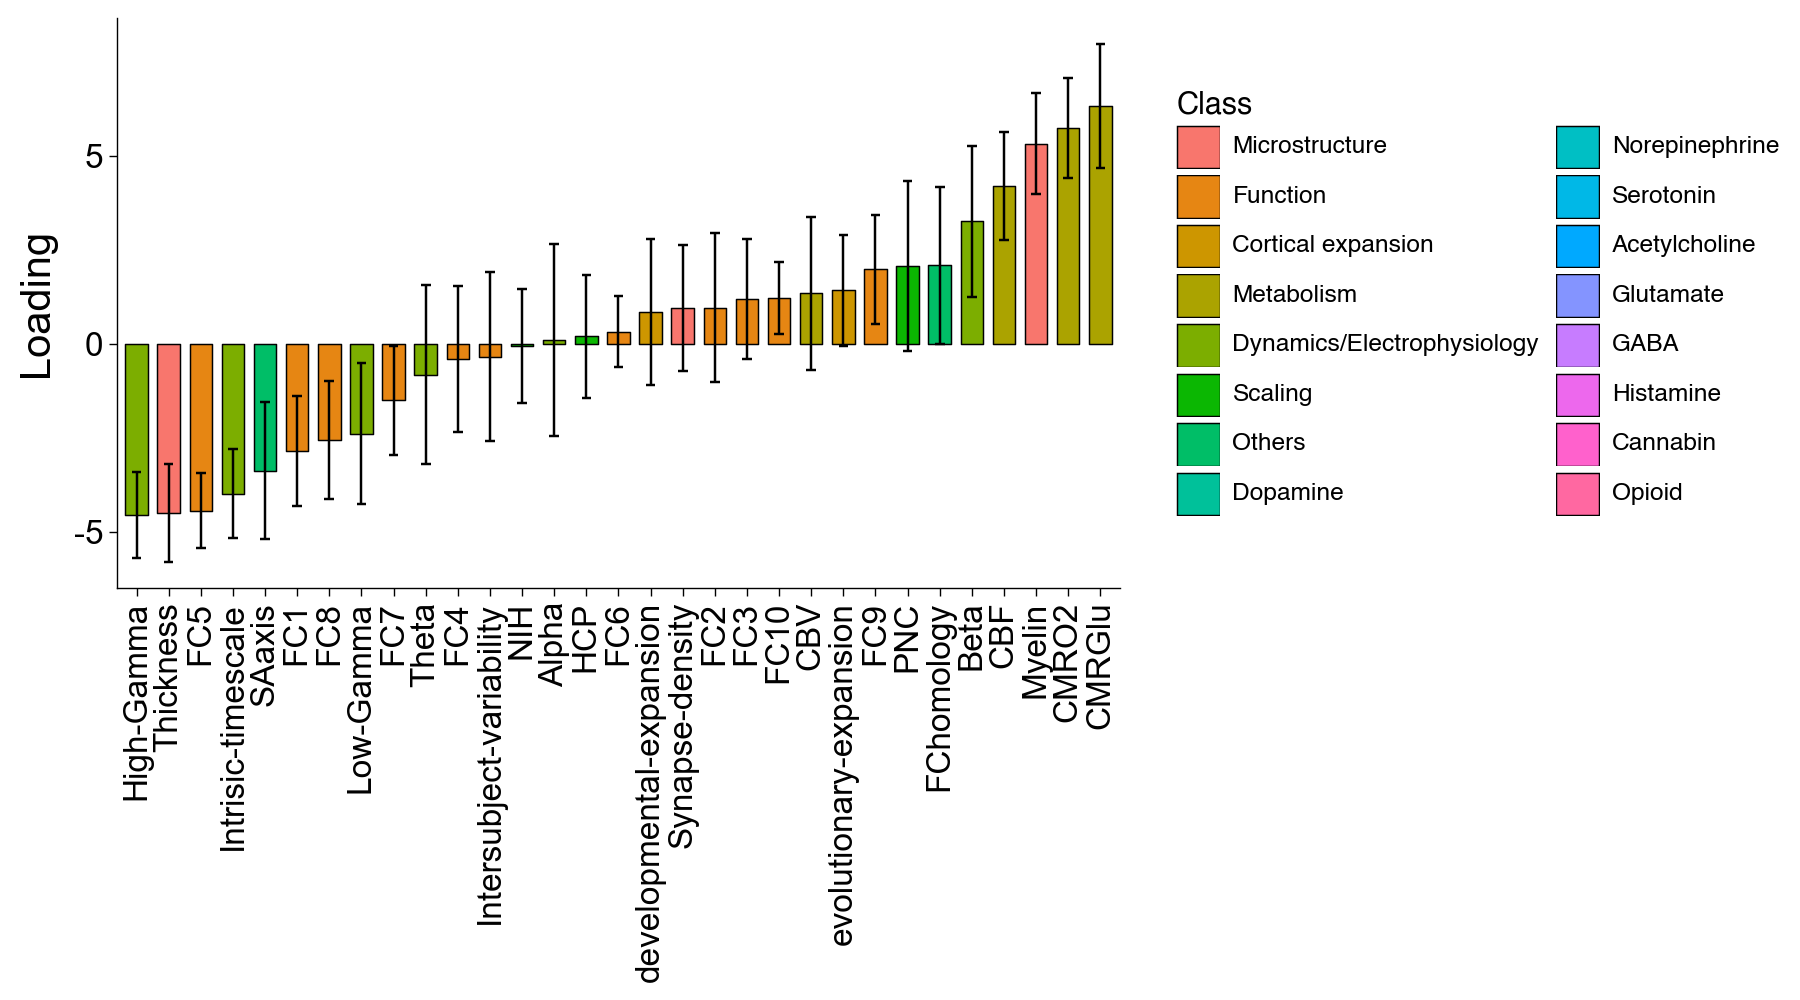

In [23]:
bar_plot = (
    p9.ggplot(mapping=p9.aes(x="X", y="Loading", fill="Class"), data=dat_bar)
    + p9.geom_bar(stat="identity", width=0.7, color="black", size=0.3)
    + p9.geom_errorbar(p9.aes(ymin="Low", ymax="High"), dat_bar, width=0.3, size=0.5)
    #+ p9.geom_hline(yintercept=[-3, 3], color="red", linetype="dashed", size=0.5)
    + p9.theme_classic()
    + p9.ylab("Loading")
    #+ p9.scale_y_continuous(breaks=[-6, -3, 0, 3, 6], limits=(-6, 9))
    #+ p9.scale_y_continuous(expand = (0, 0))
    + p9.theme(figure_size=(9, 5),
               axis_text=p9.element_text(size=12, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=90, size=12),
               axis_title=p9.element_text(size=15, color="black", family="Arial"),
               axis_title_x=p9.element_blank(),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(color="black", size=0.5),
               axis_ticks=p9.element_line(color="black", size=0.5),
               axis_ticks_minor=p9.element_blank()
               #legend_position="none",
               )
    + p9.guides(fill=p9.guide_legend(order=0, ncol=2))
)
bar_plot.save(filename="/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/08.PLS/pls_macro_PLS2.posi_nega_activate_increase_kwx.pdf", format="pdf", width=9, height=5, units="in", verbose=False)
bar_plot